In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.BIWI_HEAD_POSE)

In [3]:
path.ls()

(#50) [Path('/root/.fastai/data/biwi_head_pose/02'),Path('/root/.fastai/data/biwi_head_pose/io_sample.cpp'),Path('/root/.fastai/data/biwi_head_pose/22'),Path('/root/.fastai/data/biwi_head_pose/18'),Path('/root/.fastai/data/biwi_head_pose/10'),Path('/root/.fastai/data/biwi_head_pose/20'),Path('/root/.fastai/data/biwi_head_pose/11.obj'),Path('/root/.fastai/data/biwi_head_pose/23'),Path('/root/.fastai/data/biwi_head_pose/03'),Path('/root/.fastai/data/biwi_head_pose/16'),Path('/root/.fastai/data/biwi_head_pose/14'),Path('/root/.fastai/data/biwi_head_pose/07'),Path('/root/.fastai/data/biwi_head_pose/10.obj'),Path('/root/.fastai/data/biwi_head_pose/08.obj'),Path('/root/.fastai/data/biwi_head_pose/15'),Path('/root/.fastai/data/biwi_head_pose/04'),Path('/root/.fastai/data/biwi_head_pose/07.obj'),Path('/root/.fastai/data/biwi_head_pose/06'),Path('/root/.fastai/data/biwi_head_pose/19.obj'),Path('/root/.fastai/data/biwi_head_pose/03.obj')...]

In [4]:
(path/'01').ls()

(#1000) [Path('/root/.fastai/data/biwi_head_pose/01/frame_00419_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00083_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00216_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00387_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00173_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00481_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00223_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00021_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00377_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00148_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00434_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00175_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00188_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00419_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00403_pose.txt'),Path('/

In [5]:
img_files = get_image_files(path)
def img2pose(x): return Path(f'{str(x)[:-7]}pose.txt')
img2pose(img_files[0])

Path('/root/.fastai/data/biwi_head_pose/02/frame_00419_pose.txt')

In [6]:
im = PILImage.create(img_files[0])
im.shape

(480, 640)

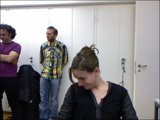

In [7]:
im.to_thumb(160)

In [8]:
cal = np.genfromtxt(path/'01'/'rgb.cal', skip_footer=6)
def get_ctr(f):
    ctr = np.genfromtxt(img2pose(f), skip_header=3)
    c1 = ctr[0] * cal[0][0]/ctr[2] + cal[0][2]
    c2 = ctr[1] * cal[1][1]/ctr[2] + cal[1][2]
    return tensor([c1,c2])

In [9]:
get_ctr(img_files[0])

tensor([344.4911, 304.3363])

In [10]:
biwi = DataBlock(
    blocks=(ImageBlock, PointBlock),
    get_items=get_image_files,
    get_y=get_ctr,
    splitter=FuncSplitter(lambda o: o.parent.name=='13'),
    batch_tfms=[*aug_transforms(size=(240,320)),
                Normalize.from_stats(*imagenet_stats)]
)

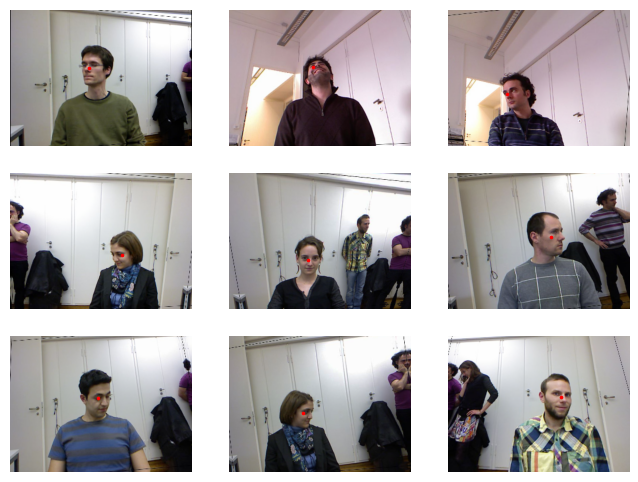

In [11]:
dls = biwi.dataloaders(path)
dls.show_batch(max_n=9, figsize=(8,6))

In [12]:
learn = vision_learner(dls, resnet18, y_range=(-1,1))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 33.1MB/s]


SuggestedLRs(valley=0.0020892962347716093)

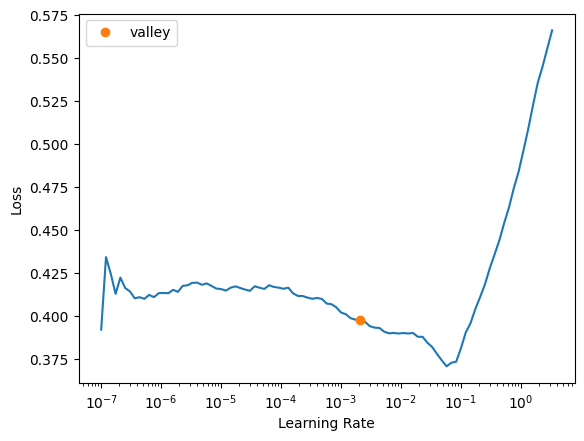

In [13]:
learn.lr_find()

In [14]:
learn.fine_tune(1, 2e-3)

epoch,train_loss,valid_loss,time
0,0.130171,0.014158,01:27


epoch,train_loss,valid_loss,time
0,0.006994,0.001639,01:35


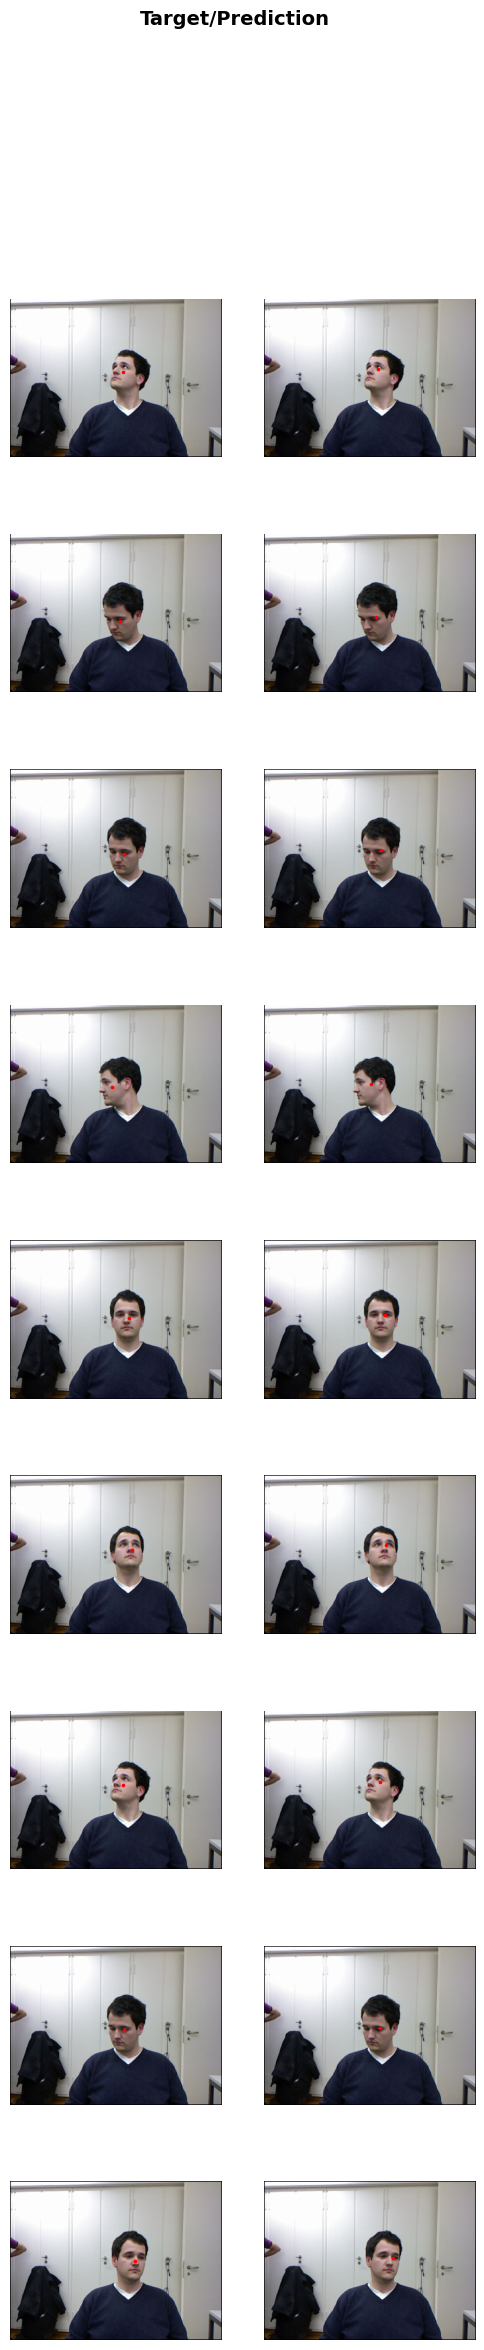

In [15]:
learn.show_results()